# Connect5 AI Arena – Data Preprocessing (fixed for actual format)
The episode JSON stores boards as 2D lists of characters (`"."`, `"x"`, `"o"`).
This notebook builds a value‑network dataset (state → outcome) and a policy‑network dataset (state → winning action).

### 1. Imports & config

In [6]:
import json
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

RAW_DATA_DIR = Path('data/episodes')
PROCESSED_DIR = Path('data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

ROWS = 9
COLS = 10

VALUE_DATA_FILE = PROCESSED_DIR / 'value_network_data.npz'
POLICY_DATA_FILE = PROCESSED_DIR / 'policy_network_data.npz'

%matplotlib inline

### 2. Board conversion functions
We convert the string board into a **2‑channel tensor from the current player’s perspective**.

In [7]:
def board_from_strings(board_list, current_player):
    """
    board_list : list of ROWS lists, each of COLS strings ("." / "x" / "o")
    current_player : "x" or "o"
    Returns np.array of shape (2, ROWS, COLS) where
        channel 0 = current player's pieces
        channel 1 = opponent's pieces
    Row 0 of the array corresponds to the BOTTOM row of the physical board.
    Our board_list has row 0 = top row, row -1 = bottom row, so we flip.
    """
    # Convert to char array and flip vertically so index 0 = bottom row
    char_grid = np.array([[cell for cell in row] for row in board_list])  # (ROWS, COLS)
    char_grid = np.flipud(char_grid)   # now row 0 = bottom

    if current_player == 'x':
        player_channel = (char_grid == 'x').astype(np.float32)
        opp_channel = (char_grid == 'o').astype(np.float32)
    else:  # current_player == 'o'
        player_channel = (char_grid == 'o').astype(np.float32)
        opp_channel = (char_grid == 'x').astype(np.float32)

    return np.stack([player_channel, opp_channel], axis=0)   # (2, ROWS, COLS)

def get_valid_actions(board_array):
    """
    board_array : (2, ROWS, COLS) where channel0/1 are pieces.
    A column is valid if the top cell (row index ROWS-1) is empty in both channels.
    """
    top_row = board_array[:, -1, :].sum(axis=0)   # sum of piece presence (0 or 1 each)
    return list(np.where(top_row == 0)[0])

def board_to_single_channel(board_array):
    """For visualisation: +1 = current player, -1 = opponent, 0 = empty."""
    return board_array[0] - board_array[1]

# Quick test on an empty board
empty_board_list = [["."]*COLS for _ in range(ROWS)]
test_board = board_from_strings(empty_board_list, 'x')
assert test_board.shape == (2, ROWS, COLS)
assert test_board.sum() == 0
assert get_valid_actions(test_board) == list(range(COLS))
print('Sanity check passed')

Sanity check passed


### 3. Parse one episode
We map player tokens to numeric IDs (x → 0, o → 1) to index the final reward list.

In [12]:
def parse_episode(episode_path):
    with open(episode_path, 'r', encoding='utf-8', errors='ignore') as f:
        ep = json.load(f)

    state_history = ep['info']['stateHistory']
    action_history = ep['info']['actionHistory']
    rewards = ep['rewards']

    states, actions, outcomes, valid_masks = [], [], [], []

    for t in range(len(action_history)):
        raw_state = state_history[t]

        # ------------------------------------------------------------
        # Some entries are serialised JSON strings – parse them first
        # ------------------------------------------------------------
        if isinstance(raw_state, str):
            raw_state = json.loads(raw_state)

        board_str = raw_state['board']
        current_player = raw_state['current_player']

        board_arr = board_from_strings(board_str, current_player)
        legal_cols = get_valid_actions(board_arr)
        
        mask = np.zeros(COLS, dtype=bool)
        mask[legal_cols] = True

        action = int(action_history[t])
        player_idx = 0 if current_player == 'x' else 1
        outcome = rewards[player_idx]

        states.append(board_arr)
        actions.append(action)
        outcomes.append(outcome)
        valid_masks.append(mask)

    return states, actions, outcomes, valid_masks


### 4. Parse all episodes

In [13]:
episode_files = sorted(RAW_DATA_DIR.glob('*.json'))
assert episode_files, f"No JSON files found in {RAW_DATA_DIR}"
print(f"Found {len(episode_files)} episodes")

all_states = []
all_actions = []
all_outcomes = []
all_masks = []

for fpath in tqdm(episode_files, desc='Parsing'):
    states, actions, outcomes, masks = parse_episode(fpath)
    all_states.extend(states)
    all_actions.extend(actions)
    all_outcomes.extend(outcomes)
    all_masks.extend(masks)

print(f"Total states: {len(all_states)}")
print(f"  Wins:  {sum(1 for o in all_outcomes if o > 0)}")
print(f"  Losses:{sum(1 for o in all_outcomes if o < 0)}")
print(f"  Draws: {sum(1 for o in all_outcomes if o == 0)}")

Found 3464 episodes


Parsing:   0%|          | 0/3464 [00:00<?, ?it/s]

Parsing: 100%|██████████| 3464/3464 [00:49<00:00, 70.08it/s]

Total states: 121518
  Wins:  57872
  Losses:56266
  Draws: 7380


### 5. Save value network dataset
All states with outcome from the perspective of the player who moved.

In [14]:
states_array = np.array(all_states, dtype=np.float32)
outcomes_array = np.array(all_outcomes, dtype=np.float32)

np.savez_compressed(VALUE_DATA_FILE,
                    states=states_array,
                    outcomes=outcomes_array)
print(f"Value dataset saved: {VALUE_DATA_FILE}")
print(f"  X shape: {states_array.shape}")
print(f"  y shape: {outcomes_array.shape}")

Value dataset saved: data\processed\value_network_data.npz
  X shape: (121518, 2, 9, 10)
  y shape: (121518,)


### 6. Save policy network dataset
Only moves from winning players (outcome > 0).

In [15]:
win_mask = np.array(all_outcomes) > 0
win_states = np.array([s for s, m in zip(all_states, win_mask) if m], dtype=np.float32)
win_actions = np.array([a for a, m in zip(all_actions, win_mask) if m], dtype=np.int32)
win_masks = np.array([m for m, w in zip(all_masks, win_mask) if w], dtype=bool)

np.savez_compressed(POLICY_DATA_FILE,
                    states=win_states,
                    actions=win_actions,
                    valid_masks=win_masks)
print(f"Policy dataset saved: {POLICY_DATA_FILE}")
print(f"  X shape: {win_states.shape}")
print(f"  y shape: {win_actions.shape}")

Policy dataset saved: data\processed\policy_network_data.npz
  X shape: (57872, 2, 9, 10)
  y shape: (57872,)


### 7. Visualise a sample board

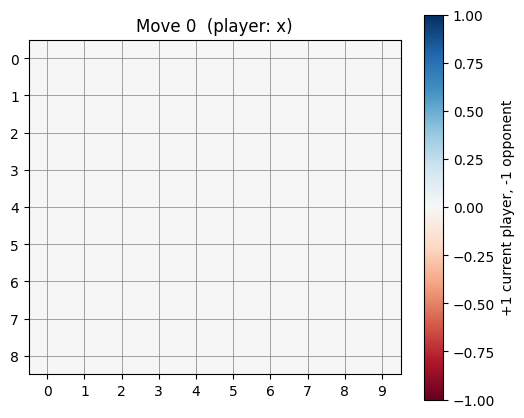

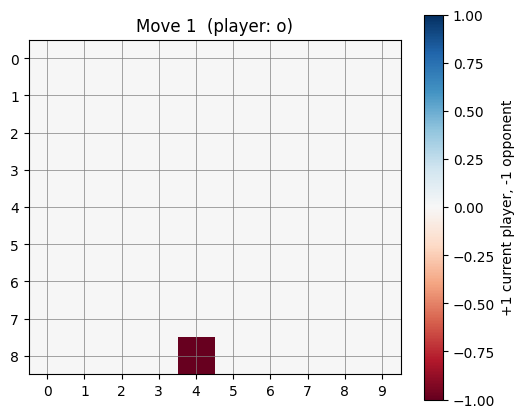

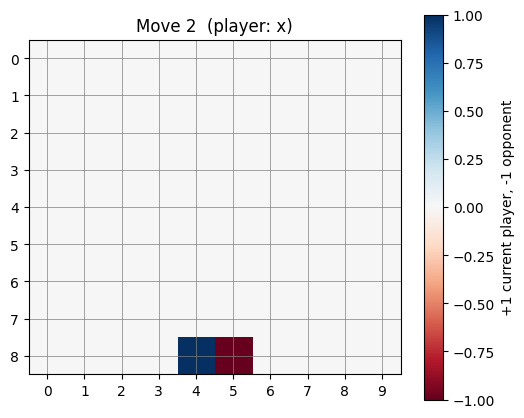

In [17]:
def plot_board(board_arr, title="Board"):
    single = board_to_single_channel(board_arr)
    fig, ax = plt.subplots(figsize=(6,5))
    # Show empty=green, player=red, opponent=blue
    cmap = plt.cm.RdBu
    im = ax.imshow(single, cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.set_xticklabels(range(COLS))
    ax.set_yticklabels(range(ROWS))
    ax.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='+1 current player, -1 opponent')
    plt.show()

# Example: first episode, first three states
with open(episode_files[0], 'r', encoding='utf-8', errors='ignore') as f:
    sample = json.load(f)

if len(sample['info']['stateHistory']) >= 3:
    for i in range(3):
        st = sample['info']['stateHistory'][i]
        board_arr = board_from_strings(st['board'], st['current_player'])
        plot_board(board_arr, f"Move {i}  (player: {st['current_player']})")
else:
    print("Episode has fewer than 3 states")